# PyPSA: Sector-Coupling

<img src="https://docs.pypsa.org/latest/assets/logo/logo-primary-light.svg#only-light" width="300px" />

:::{note}
If you have not yet set up Python on your computer, you can execute this tutorial in your browser via [Google Colab](https://colab.research.google.com/). Download the `.ipynb` file using the download button on the top right corner and import it in [Google Colab](https://colab.research.google.com/).

Then install the following packages by executing the following command in a Jupyter cell at the top of the notebook.

```sh
!pip install pypsa pandas numpy matplotlib plotly
```
:::

:::{note}
Also in this tutorial, you might want to refer to the PyPSA documentation: https://docs.pypsa.org.
:::

In [16]:
import pypsa
import numpy as np
import pandas as pd
import plotly.io as pio
import plotly.offline as py
import matplotlib.pyplot as plt

from pypsa.costs import annuity

pd.options.plotting.backend = "plotly"

SOLVER = "highs"

In [17]:
pypsa.options.params.optimize.include_objective_constant = True

## Previously

To explore sector-coupling options with PyPSA, let's load the capacity expansion model we built for the electricity system and add sector-coupling technologies and demands on top. 

In [18]:
url = "https://tubcloud.tu-berlin.de/s/kpWaraGc9LeaxLK/download/network-cem.nc"
n = pypsa.Network(url)
n

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, loads, storage_units, sub_networks


PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1
 - Carrier: 7
 - Generator: 4
 - GlobalConstraint: 1
 - Load: 1
 - StorageUnit: 2
 - SubNetwork: 1
Snapshots: 2190

## Hydrogen

The following example shows how to model the components of hydrogen storage separately, i.e. electrolysis, fuel cell and storage.

First, let's remove the simplified hydrogen storage representation from the previous electricity model:

In [19]:
n.remove("StorageUnit", "hydrogen storage underground")

Add a separate `Bus` for the hydrogen energy carrier:

In [20]:
n.add("Bus", "hydrogen", carrier="hydrogen")

Add a `Link` for the hydrogen electrolysis:

In [21]:
n.add(
    "Link",
    "electrolysis",
    bus0="electricity",
    bus1="hydrogen",
    carrier="electrolysis",
    p_nom_extendable=True,
    efficiency=0.65,
    capital_cost=annuity(0.07, 25) * 1_500_000,  # €/MW/a
)

Add a `Link` for the fuel cell which reconverts hydrogen to electricity:

In [22]:
n.add(
    "Link",
    "fuel cell",
    bus0="hydrogen",
    bus1="electricity",
    carrier="fuel cell",
    p_nom_extendable=True,
    efficiency=0.45,
    capital_cost=annuity(0.07, 25) * 550_000,  # €/MW/a
)

Add a `Store` for the hydrogen storage:

In [23]:
n.add(
    "Store",
    "hydrogen storage",
    bus="hydrogen",
    carrier="hydrogen storage",
    capital_cost=annuity(0.07, 100) * 2_000,  # €/MWh/a
    e_nom_extendable=True,
    e_cyclic=True,  # cyclic state of charge
)

We can also add a hydrogen demand to the hydrogen bus.

In the example below, we add a constant hydrogen demand the size of the electricity demand.

In [24]:
p_set = n.loads_t.p_set["demand"].mean()

In [25]:
p_set

np.float64(54671.88812785388)

In [26]:
n.add("Load", "hydrogen demand", bus="hydrogen", carrier="hydrogen", p_set=p_set)  # MW

Add new `Carrier` extensions (only used for plotting):

In [27]:
n.add(
    "Carrier",
    ["hydrogen", "electrolysis", "fuel cell", "hydrogen storage", "hydrogen demand"],
    color=["cyan", "magenta", "orange", "purple", "cyan"],
);

When we now optimize the model with additional hydrogen demand...

In [28]:
n.optimize(solver_name=SOLVER, log_to_console=False)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 504.81it/s]
INFO:linopy.io: Writing time: 0.12s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 24098 primals, 52569 duals
Objective: 1.08e+11
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

...we can see the individual sizing of the electrolyser, fuel cell and hydrogen storage:

In [29]:
n.statistics.optimal_capacity().div(1e3).round(2)

component    carrier         
Generator    offwind               205.02
             onwind                 70.07
             solar                 517.37
Link         electrolysis          168.53
             fuel cell              76.06
StorageUnit  battery storage       102.25
Store        hydrogen storage    38605.18
dtype: float64

Furthermore, we might want to explore the storage state of charge of the hydrogen storage and the balancing patterns:

In [30]:
n.stores_t.e.div(1e6).plot()  # TWh

The energy balance we can now inspect by different bus carriers:

In [31]:
n.statistics.energy_balance.iplot.area(bus_carrier="electricity")

In [32]:
n.statistics.energy_balance.iplot.area(bus_carrier="hydrogen")

## Heating

For modelling simple heating systems, we create another bus and connect a load with the heat demand time series to it.

In [33]:
n.add("Bus", "heat", carrier="heat")

In [34]:
url = "https://tubcloud.tu-berlin.de/s/mSkHERH8fJCKNXx/download/heat-load-example.csv"
p_set = pd.read_csv(url, index_col=0, parse_dates=True).squeeze()

In [35]:
p_set

snapshot
2015-01-01 00:00:00     61726.043437
2015-01-01 04:00:00    108787.133591
2015-01-01 08:00:00    101508.988082
2015-01-01 12:00:00     90475.260586
2015-01-01 16:00:00     96307.755312
                           ...      
2015-12-31 04:00:00    136864.752819
2015-12-31 08:00:00    127402.962584
2015-12-31 12:00:00    113058.812208
2015-12-31 16:00:00    120641.215416
2015-12-31 20:00:00    111934.748838
Name: 0, Length: 2190, dtype: float64

In [36]:
n.add("Load", "heat demand", carrier="heat", bus="heat", p_set=p_set)

In [37]:
n.loads_t.p_set.div(1e3).plot(labels=dict(value="Power (GW)"))

What is missing now are the components to supply heat to the `"heat"` bus, such as heat pumps, resistive heaters or combined heat and power plants (CHPs).

### Heat pumps

To model heat pumps, first we have to calculate the **coefficient of performance (COP)** profile based on the temperature profile of the heat source.

In the example below, we calculate the COP for an air-sourced heat pump with a sink temperature of 55° C and a population-weighted ambient temperature profile for Germany.

The heat pump performance is given by the following function:

$$
COP(\Delta T) = 6.81 - 0.121 \Delta T + 0.00063^\Delta T^2
$$
where $\Delta T = T_{sink} - T_{source}$.

In [38]:
def cop(t_source, t_sink=55):
    delta_t = t_sink - t_source
    return 6.81 - 0.121 * delta_t + 0.000630 * delta_t**2

In [39]:
url = "https://tubcloud.tu-berlin.de/s/S4jRAQMP5Te96jW/download/ninja_weather_country_DE_merra-2_population_weighted.csv"
temp = pd.read_csv(url, skiprows=2, index_col=0, parse_dates=True).loc[
    "2015", "temperature"
][::4]

In [40]:
cop(temp).plot()

Text(0, 0.5, 'COP [-]')

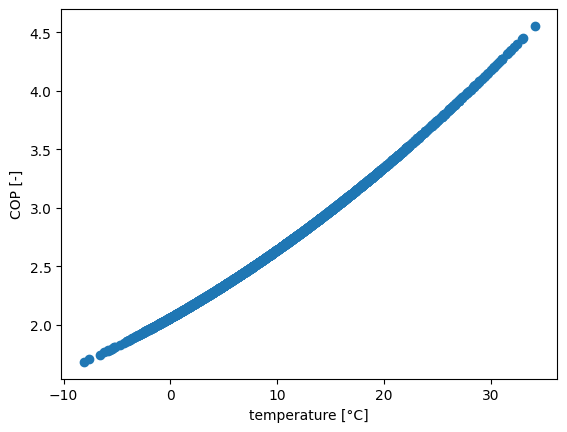

In [41]:
plt.scatter(temp, cop(temp))
plt.xlabel("temperature [°C]")
plt.ylabel("COP [-]")

Once we have calculated the heat pump coefficient of performance, we can add the heat pump to the network as a `Link`. We use the parameter `efficiency` to incorporate the COP.

In [42]:
n.add(
    "Link",
    "heat pump",
    carrier="heat pump",
    bus0="electricity",
    bus1="heat",
    efficiency=cop(temp),
    p_nom_extendable=True,
    capital_cost=annuity(0.05, 18) * 280_000,  # €/MWe/a
)

In [43]:
n.links_t.efficiency.head()

name,heat pump
snapshot,
2015-01-01 00:00:00,2.010639
2015-01-01 04:00:00,1.998313
2015-01-01 08:00:00,2.007361
2015-01-01 12:00:00,2.156823
2015-01-01 16:00:00,2.052803


### Resistive Heaters

Let's also add a resistive heater as backup technology:

In [44]:
n.add(
    "Link",
    "resistive heater",
    carrier="resistive heater",
    bus0="electricity",
    bus1="heat",
    efficiency=0.9,
    capital_cost=annuity(0.05, 20) * 120_000,  # €/MWe/a
    p_nom_extendable=True,
)

Let's also not forget to add the new `Carrier` extensions for plotting:

In [45]:
n.add(
    "Carrier",
    ["heat", "heat demand", "heat pump", "resistive heater"],
    color=["firebrick", "firebrick", "lime", "khaki"],
);

### Combined Heat-and-Power (CHP)

In the following, we are going to add gas-fired combined heat-and-power plants (CHPs). Today, these would use fossil gas, but in the example below we assume green methane with relatively high marginal costs. Since we have no other net emission technology, we can remove the CO$_2$ limit from the previous electricity-only model.

In [46]:
n.remove("GlobalConstraint", "CO2Limit")

Then, we explicitly represent the energy carrier `"gas"`:

In [47]:
n.add("Bus", "gas", carrier="gas")

And add a `Store` of gas, which can be depleted (up to 100 TWh) with fuel costs of 150 €/MWh.

In [48]:
n.add(
    "Store",
    "gas storage",
    carrier="gas storage",
    e_initial=100e6,  # MWh
    e_nom=100e6,  # MWh
    bus="gas",
    marginal_cost=150,  # €/MWh_th
)

When we do this, we have to model the OCGT power plant as `Link` which converts gas to electricity, **not** as `Generator`.

In [49]:
n.remove("Generator", "OCGT")

In [50]:
n.add(
    "Link",
    "OCGT",
    bus0="gas",
    bus1="electricity",
    carrier="OCGT",
    p_nom_extendable=True,
    capital_cost=annuity(0.07, 25) * 450_000,  # €/MW/a
    efficiency=0.4,
)

Next, we are going to add a combined heat-and-power (CHP) plant with fixed heat-power ratio (i.e. backpressure operation).

PyPSA can automatically handle links that have more than one input (in addition to `bus0`) and/or output (i.e. `bus1`, `bus2`, `bus3`) with a given efficieny (`efficiency`, `efficiency2`, `efficiency3`) that can also be negative to denote additional inputs.

In [51]:
n.add(
    "Link",
    "CHP",
    bus0="gas",
    bus1="electricity",
    bus2="heat",
    carrier="CHP",
    p_nom_extendable=True,
    capital_cost=annuity(0.07, 25) * 600_000,
    efficiency=0.4,
    efficiency2=0.4,
)

And we should not forget to add the carriers for plotting:

In [52]:
n.add("Carrier", ["gas", "gas storage", "CHP"], color=["peru", "tan", "sienna"]);

Now, let’s optimize the current status of model:

In [53]:
n.optimize(solver_name=SOLVER, log_to_console=False)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 652.47it/s]
INFO:linopy.io: Writing time: 0.1s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35051 primals, 76661 duals
Objective: 1.42e+11
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

The objective cost in bn€/a:

In [54]:
n.objective / 1e9

141.78020874006657

The heat energy balance (positive is supply, negative is consumption):

In [55]:
n.statistics.energy_balance(bus_carrier="heat").div(1e6).round(1)

component  carrier    bus_carrier
Link       heat pump  heat           557.1
           CHP        heat            36.5
Load       heat       heat          -593.7
dtype: float64

The electricity energy balance (positive is supply, negative is consumption):

In [57]:
n.statistics.energy_balance(bus_carrier="electricity").sort_values().div(1e6).round(1)

component    carrier          bus_carrier
Link         electrolysis     electricity   -750.6
Load         -                electricity   -478.9
Link         heat pump        electricity   -235.2
StorageUnit  battery storage  electricity     -7.6
Link         fuel cell        electricity      4.0
             CHP              electricity     36.5
Generator    onwind           electricity     99.0
             solar            electricity    539.1
             offwind          electricity    793.7
dtype: float64

The heat energy balance as a time series:

In [58]:
n.statistics.energy_balance.iplot.area(bus_carrier="heat")

The electricity energy balance as a time series:

In [60]:
n.statistics.energy_balance.iplot.area(bus_carrier="electricity")

### Long-duration Heat Storage

One technology of particular interest in district heating systems with large shares of renewables is long-duration thermal energy storage.

In the following, we are going to introduce a heat storage with investment cost of approximately 3 €/kWh. The energy is not perfectly stored in water tanks. There are standing losses. The decay of thermal energy in the heat storage is modelled through the function $1-e^{-\frac{1}{24\tau}}$, where $\tau$ is assumed to be 180 days. We want to see how that influences the optimal design decisions in the heating sector.

In [61]:
n.add(
    "Store",
    "heat storage",
    bus="heat",
    carrier="heat storage",
    capital_cost=300,  # roughly annuity of 3 €/kWh/a
    standing_loss=1 - np.exp(-1 / 24 / 180),
    e_nom_extendable=True,
)

n.add("Carrier", "heat storage", color="teal")

n.optimize(solver_name=SOLVER, log_to_console=False)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 454.96it/s]
INFO:linopy.io: Writing time: 0.12s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 39432 primals, 83232 duals
Objective: 1.29e+11
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

The objective cost (in bn€/a) was reduced.

In [62]:
n.objective / 1e9

128.89212115690722

The heat energy balance shows the additional losses of the heat storage and the added supply:

In [63]:
n.statistics.energy_balance(bus_carrier="heat").div(1e6).round(1)

component  carrier       bus_carrier
Link       heat pump     heat           596.8
           CHP           heat             7.8
Load       heat          heat          -593.7
Store      heat storage  heat           -10.9
dtype: float64

In [64]:
n.statistics.energy_balance.iplot.area(bus_carrier="heat")

The different storage state of charge time series:

In [65]:
n.stores_t.e.drop("gas storage", axis=1).plot()

## Electric Vehicles

To model electric vehicles, we first create another bus for the electric vehicles.

In [66]:
n.add("Bus", "EV", carrier="EV")

Then, we can attach the electricity consumption of electric vehicles to this bus:

In [68]:
url = "https://tubcloud.tu-berlin.de/s/9r5bMSbzzQiqG7H/download/electric-vehicle-profile-example.csv"
p_set = pd.read_csv(url, index_col=0, parse_dates=True).squeeze()
p_set.loc["2015-01"].div(1e3).plot()

In [69]:
n.add("Load", "EV demand", bus="EV", carrier="EV demand", p_set=p_set)

The electric vehicles can only be charged when they are plugged-in. Below we load an availability profile
telling us what share of electric vehicles is plugged-in **at home** -- we only assume home charging in this example.

In [70]:
url = "https://tubcloud.tu-berlin.de/s/E3PBWPfYaWwCq7a/download/electric-vehicle-availability-example.csv"
availability_profile = pd.read_csv(url, index_col=0, parse_dates=True).squeeze()
availability_profile.loc["2015-01"].plot()

Then, we can add a link for the electric vehicle charger using assumption about the number of EVs and their charging rates.

In [71]:
number_cars = 40e6  #  number of EV cars
bev_charger_rate = 0.011  # 3-phase EV charger with 11 kW
p_nom = number_cars * bev_charger_rate

In [72]:
n.add(
    "Link",
    "EV charger",
    bus0="electricity",
    bus1="EV",
    p_nom=p_nom,
    carrier="EV charger",
    p_max_pu=availability_profile,
    efficiency=0.9,
)

We can also allow vehicle-to-grid operation (i.e. electric vehicles inject power into the grid):

In [73]:
n.add(
    "Link",
    "V2G",
    bus0="EV",
    bus1="electricity",
    p_nom=p_nom,
    carrier="V2G",
    p_max_pu=availability_profile,
    efficiency=0.9,
)

The demand-side management potential we model as a store. This is not unlike a battery storage, but we impose additional constraints on when the store needs to be charged to a certain level (e.g. 75% full every morning).

In [74]:
bev_energy = 0.05  # average battery size of EV in MWh
bev_dsm_participants = 0.5  # share of cars that do smart charging

e_nom = number_cars * bev_energy * bev_dsm_participants

In [76]:
dsm_profile = pd.Series(0.0, index=n.snapshots)
dsm_profile.where(dsm_profile.index.hour != 8, 0.75, inplace=True)
dsm_profile.loc["2015-01"].plot()

In [77]:
n.add(
    "Store",
    "EV DSM",
    bus="EV",
    carrier="EV battery",
    e_cyclic=True,  # state of charge at beginning = state of charge at the end
    e_nom=e_nom,
    e_min_pu=dsm_profile,
)

And again add the new `Carrier` extensions for plotting:

In [78]:
n.add(
    "Carrier",
    ["EV", "EV demand", "EV charger", "V2G", "EV battery"],
    color=["cadetblue", "cadetblue", "limegreen", "limegreen", "teal"],
);

Then, we can solve the fully sector-coupled model altogether including electricity, passenger transport, hydrogen and heating.

In [ ]:
n.optimize(solver_name=SOLVER, log_to_console=False)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 529.10it/s]
INFO:linopy.io: Writing time: 0.12s


In [ ]:
n.objective / 1e9

In [ ]:
n.statistics.energy_balance(bus_carrier="electricity").div(1e6).round(1)

In [ ]:
n.statistics.energy_balance.iplot.area(bus_carrier="electricity")

In [ ]:
n.statistics.energy_balance.iplot.area(bus_carrier="EV")

## Exercises

Explore how the model reacts to changing assumptions and available technologies. Here are a few inspirations, but choose in any order according to your interests:

**Task 1:** Assume underground hydrogen storage is not geographically available. Increase the cost of hydrogen storage by factor 10. How does the model react? You can alter the costs with `n.stores.loc["StoreName", "capital_cost"] *= 10`.

**Task 2:** Add a ground-sourced heat pump with a constant COP function of 3.5 but double the investment costs. Would this technology get built? How low would the costs need to be? You can add the technology with `n.add("Link", "ground-sourced heat pump", bus0=..., bus1=..., efficiency=..., capital_cost=...)`.

**Task 3:** Limit green gas imports to 10 TWh or even zero. What does the model do in periods with persistent low wind and solar feed-in but high heating demand? You can alter the initial filling level of the gas store with `n.stores.loc["gas storage", "e_initial"] = 10e6`.